# **Solving Second-Order Equations**

The following code implements **Method 1** for solving the equation $\frac{d^2u}{dt^2} = -\,u$,$ t\in[0,1]$, subject to boundary conditions $u(0)=1$, $u(1)=\cos(1)$. In this method the loss function enforces both the boundary conditions and the equation.

Epoch 1/250, Loss: 7.115070
Epoch 2/250, Loss: 2.343326
Epoch 3/250, Loss: 0.684293
Epoch 4/250, Loss: 1.277954
Epoch 5/250, Loss: 0.919380
Epoch 6/250, Loss: 0.406470
Epoch 7/250, Loss: 0.287491
Epoch 8/250, Loss: 0.254503
Epoch 9/250, Loss: 0.300655
Epoch 10/250, Loss: 0.153150
Epoch 11/250, Loss: 0.130076
Epoch 12/250, Loss: 0.105491
Epoch 13/250, Loss: 0.112733
Epoch 14/250, Loss: 0.077211
Epoch 15/250, Loss: 0.067217
Epoch 16/250, Loss: 0.059694
Epoch 17/250, Loss: 0.055514
Epoch 18/250, Loss: 0.045892
Epoch 19/250, Loss: 0.040365
Epoch 20/250, Loss: 0.037592
Epoch 21/250, Loss: 0.033529
Epoch 22/250, Loss: 0.030023
Epoch 23/250, Loss: 0.027362
Epoch 24/250, Loss: 0.025502
Epoch 25/250, Loss: 0.023207
Epoch 26/250, Loss: 0.021220
Epoch 27/250, Loss: 0.019887
Epoch 28/250, Loss: 0.018407
Epoch 29/250, Loss: 0.017021
Epoch 30/250, Loss: 0.016012
Epoch 31/250, Loss: 0.014988
Epoch 32/250, Loss: 0.014006
Epoch 33/250, Loss: 0.013249
Epoch 34/250, Loss: 0.012520
Epoch 35/250, Loss: 0.0

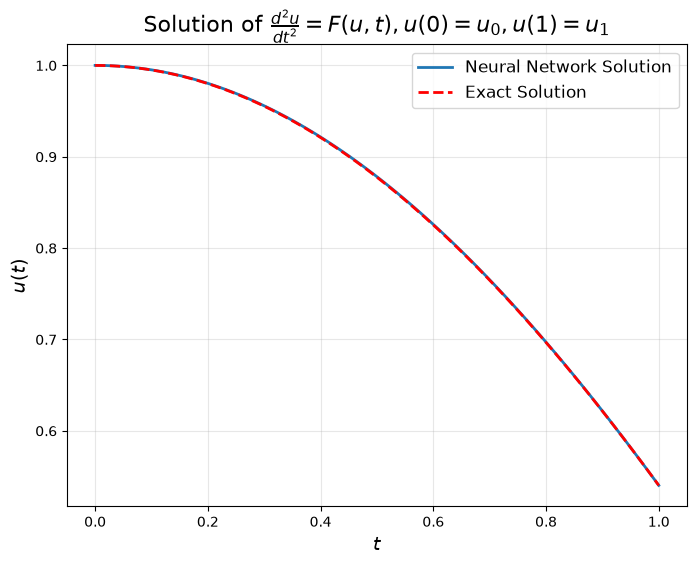

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Define the function F(u, t) (example problem)
def F(u, t):
    return -u  # Example: Simple harmonic motion (d^2u/dt^2 = -u)

# Define the exact solution for comparison (if known)
def exact_solution(t):
    return np.cos(t)  # Exact solution for F(u, t) = -u, u(0) = 1, u(1) = np.cos(1)

# Boundary conditions
u_0 = 1.0  # u(0)
u_1 = np.cos(1)  # u(1)

# Neural network to approximate u(t)
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 50),  # Hidden layer with 50 neurons
            nn.Tanh(),
            nn.Linear(50, 1)   # Output layer
        )

    def forward(self, x):
        return self.network(x)

model = NN()

# Generate training data: time points in [0, 1]
t_train = np.linspace(0, 1, 100).reshape(-1, 1)
t_train = torch.tensor(t_train, dtype=torch.float32)

dummy_target = torch.zeros_like(t_train)  # Dummy target, as the loss handles everything

# Create DataLoader (same batch size as TensorFlow)
dataset = TensorDataset(t_train, dummy_target)
train_loader = DataLoader(dataset, batch_size=32, shuffle=False)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Custom loss function
def custom_loss(t_input):

    # Enable gradient computation with respect to t
    t_input = t_input.clone().detach().requires_grad_(True)

    # Compute NN(theta, t) and its derivatives
    nn_t = model(t_input)

    d_nn_dt = torch.autograd.grad(
        outputs=nn_t,
        inputs=t_input,
        grad_outputs=torch.ones_like(nn_t),
        create_graph=True
    )[0]  # First derivative

    d2_nn_dt2 = torch.autograd.grad(
        outputs=d_nn_dt,
        inputs=t_input,
        grad_outputs=torch.ones_like(d_nn_dt),
        create_graph=True
    )[0]  # Second derivative

    # Equation loss: d^2u/dt^2 - F(u, t)
    equation_loss = torch.mean((d2_nn_dt2 - F(nn_t, t_input)) ** 2)

    # Boundary condition loss: (NN(theta, 0) - u_0)^2 + (NN(theta, 1) - u_1)^2
    t0 = torch.tensor([[0.0]], dtype=torch.float32)
    t1 = torch.tensor([[1.0]], dtype=torch.float32)

    boundary_loss = (
        (model(t0) - u_0) ** 2 +
        (model(t1) - u_1) ** 2
    ).mean()

    # Total loss
    return equation_loss + 10 * boundary_loss

# Train the model
epochs = 250

for epoch in range(epochs):

    epoch_loss = 0.0

    for t_batch, _ in train_loader:

        optimizer.zero_grad()

        loss = custom_loss(t_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.6f}")

# Generate points for plotting
t_plot = np.linspace(0, 1, 100).reshape(-1, 1)
t_plot_tensor = torch.tensor(t_plot, dtype=torch.float32)

with torch.no_grad():
    u_nn = model(t_plot_tensor).numpy()  # Neural network solution

u_exact = exact_solution(t_plot)  # Exact solution

# Plot the solutions
plt.figure(figsize=(8, 6))
plt.plot(t_plot, u_nn, label="Neural Network Solution", linewidth=2)
plt.plot(t_plot, u_exact, label="Exact Solution", linewidth=2, color='red', linestyle='dashed')
plt.title("Solution of $\\frac{d^2u}{dt^2} = F(u, t), u(0) = u_0, u(1) = u_1$", fontsize=16)
plt.xlabel("$t$", fontsize=14)
plt.ylabel("$u(t)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

The next code implements **Method 2** for solving the equation $\frac{d^2u}{dt^2} = -\,u$,$ t\in[0,1]$, subject to boundary conditions $u(0)=1$, $u(1)=\cos(1)$. In this method we use the trial solution  $u(t) = (1-t) u_0 + t u_1 + t(1-t) f_{\theta}(t)$ and train the neural network $f_{\theta}(t)$.

Epoch 1/250 - loss: 0.708396
Epoch 2/250 - loss: 0.562554
Epoch 3/250 - loss: 0.182528
Epoch 4/250 - loss: 0.035410
Epoch 5/250 - loss: 0.069976
Epoch 6/250 - loss: 0.009443
Epoch 7/250 - loss: 0.026975
Epoch 8/250 - loss: 0.006414
Epoch 9/250 - loss: 0.010837
Epoch 10/250 - loss: 0.003339
Epoch 11/250 - loss: 0.004508
Epoch 12/250 - loss: 0.002148
Epoch 13/250 - loss: 0.002219
Epoch 14/250 - loss: 0.001694
Epoch 15/250 - loss: 0.001132
Epoch 16/250 - loss: 0.001018
Epoch 17/250 - loss: 0.000531
Epoch 18/250 - loss: 0.000659
Epoch 19/250 - loss: 0.000480
Epoch 20/250 - loss: 0.000399
Epoch 21/250 - loss: 0.000504
Epoch 22/250 - loss: 0.000513
Epoch 23/250 - loss: 0.000287
Epoch 24/250 - loss: 0.000254
Epoch 25/250 - loss: 0.000275
Epoch 26/250 - loss: 0.000195
Epoch 27/250 - loss: 0.000253
Epoch 28/250 - loss: 0.000164
Epoch 29/250 - loss: 0.000164
Epoch 30/250 - loss: 0.000128
Epoch 31/250 - loss: 0.000156
Epoch 32/250 - loss: 0.000132
Epoch 33/250 - loss: 0.000113
Epoch 34/250 - loss

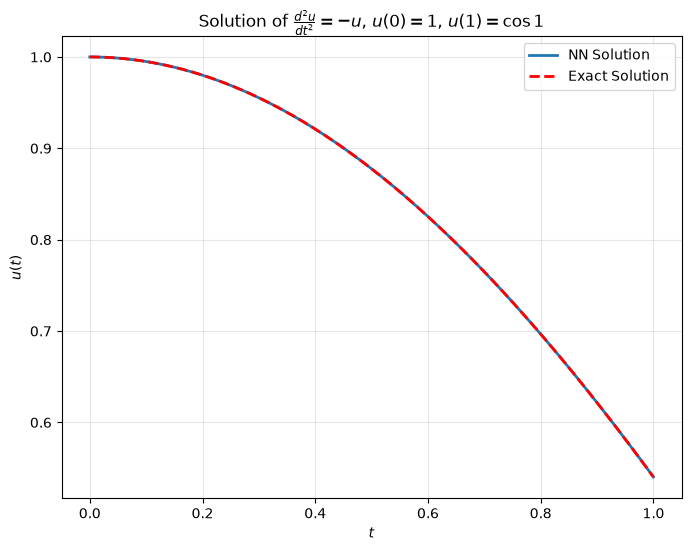

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Problem setup
def F(u, t):
    # Right‐hand side of the ODE: d^2u/dt^2 = –u
    return -u

u0 = 1.0                # u(0)
u1 = np.cos(1.0)        # u(1)

# 2. Training data (collocation points in [0,1])
t_train = torch.linspace(0, 1, 100, dtype=torch.float32).view(-1, 1)
t_train.requires_grad_(True)                       # need gradients w.r.t. t

# 3. Build the network that models the correction term NN(θ,t)
model = nn.Sequential(
    nn.Linear(1, 50),
    nn.Tanh(),
    nn.Linear(50, 50),
    nn.Tanh(),
    nn.Linear(50, 1)
)

# 4. Custom loss enforcing the differential equation and built‐in BCs
def custom_loss(t):
    nn_out = model(t)                              # NN(θ,t)
    # Trial solution: u(t) = (1–t)u0 + t u1 + t(1–t)*NN(θ,t)
    u = (1 - t) * u0 + t * u1 + t * (1 - t) * nn_out

    du_dt = torch.autograd.grad(
        u, t, grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]                                            # 1st derivative
    d2u_dt2 = torch.autograd.grad(
        du_dt, t, grad_outputs=torch.ones_like(du_dt),
        create_graph=True
    )[0]                                            # 2nd derivative

    # residual of the ODE
    eq_loss = torch.mean((d2u_dt2 - F(u, t)) ** 2)
    return eq_loss

# 5. Compile & train
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 250
batch_size = 32
n_samples = t_train.shape[0]                       # 100 collocation points

for epoch in range(epochs):
    # shuffle each epoch, like Keras' model.fit() does by default
    perm = torch.randperm(n_samples)
    epoch_loss = 0.0

    for start in range(0, n_samples, batch_size):
        idx = perm[start:start + batch_size]
        # index, then detach+re-enable grad so autograd treats it as a leaf
        t_batch = t_train[idx].detach().requires_grad_(True)

        optimizer.zero_grad()
        loss = custom_loss(t_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(idx)

    epoch_loss /= n_samples
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f}")

# 6. Evaluate & plot
t_plot = torch.linspace(0, 1, 200, dtype=torch.float32).view(-1, 1)
with torch.no_grad():
    nn_pred = model(t_plot).numpy()

t_plot_np = t_plot.numpy()
u_nn = (1 - t_plot_np) * u0 + t_plot_np * u1 + t_plot_np * (1 - t_plot_np) * nn_pred
u_exact = np.cos(t_plot_np)

plt.figure(figsize=(8, 6))
plt.plot(t_plot_np, u_nn,    label="NN Solution", linewidth=2)
plt.plot(t_plot_np, u_exact, label="Exact Solution", linestyle='--', color='red', linewidth=2)
plt.title(r"Solution of $\frac{d^2u}{dt^2}=-u$, $u(0)=1$, $u(1)=\cos1$")
plt.xlabel("$t$")
plt.ylabel("$u(t)$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The following code considers the aforementioned boundary problem with boundary conditions $u(0)=1$ and $u(15) = \cos 15$. We notice that the neural network struggles to learn the exact solution.

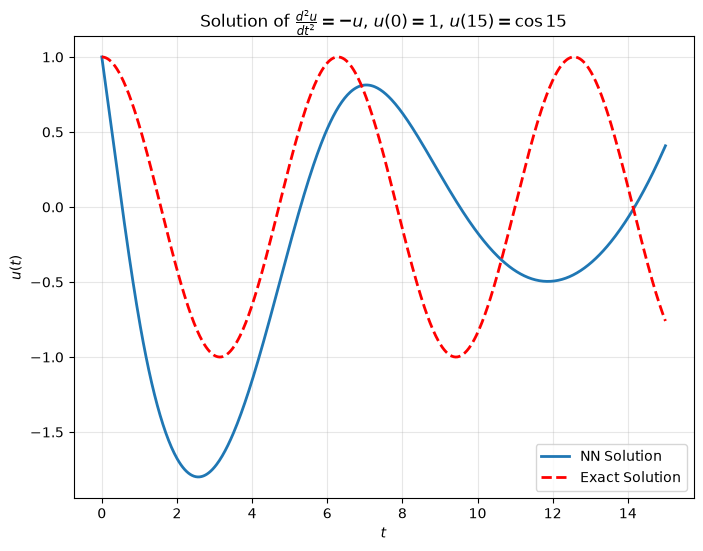

In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Problem setup
def F(u, t):
    # Right‐hand side of the ODE: d^2u/dt^2 = –u
    return -u

u0 = 1.0                # u(0)
u1 = np.cos(15.0)        # u(1)

# 2. Training data (collocation points in [0,3])
t_train = torch.linspace(0, 15, 600, dtype=torch.float32).unsqueeze(1)
t_train.requires_grad_(True)   # need gradients w.r.t. t for the ODE residual

# 3. Build the network that models the correction term NN(θ,t)
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, t):
        return self.net(t)

model = PINN()

# 4. Custom loss enforcing the differential equation and built‐in BCs
def custom_loss(t):
    nn_out = model(t)                          # NN(θ,t)
    # Trial solution: u(t) = (1–t)u0 + t u1 + t(1–t)*NN(θ,t)
    u = (1 - t)*u0 + t*u1 + t*(1 - t)*nn_out

    du_dt = torch.autograd.grad(
        u, t, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]                                        # 1st derivative
    d2u_dt2 = torch.autograd.grad(
        du_dt, t, grad_outputs=torch.ones_like(du_dt),
        create_graph=True, retain_graph=True
    )[0]                                        # 2nd derivative

    # residual of the ODE
    eq_loss = torch.mean((d2u_dt2 - F(u, t))**2)
    return eq_loss

# 5. Compile & train
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(250):
    optimizer.zero_grad()
    loss = custom_loss(t_train)
    loss.backward()
    optimizer.step()

# 6. Evaluate & plot
t_plot = torch.linspace(0, 15, 600, dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    nn_pred = model(t_plot).numpy()

t_plot_np = t_plot.numpy()
u_nn = (1 - t_plot_np)*u0 + t_plot_np*u1 + t_plot_np*(1 - t_plot_np)*nn_pred
u_exact = np.cos(t_plot_np)

plt.figure(figsize=(8,6))
plt.plot(t_plot_np, u_nn,    label="NN Solution", linewidth=2)
plt.plot(t_plot_np, u_exact, label="Exact Solution", linestyle='--', color='red', linewidth=2)
plt.title(r"Solution of $\frac{d^2u}{dt^2}=-u$, $u(0)=1$, $u(15)=\cos15$")
plt.xlabel("$t$")
plt.ylabel("$u(t)$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()